In [6]:
#import libraries & load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

# Define the path to the Excel file
file_path = r"C:\Users\keyag\OneDrive\Desktop\Churn_Analysis\Prediction_Data.xlsx"

# Define the sheet name to read data from
sheet_name = 'vw_churnsData'

# Read the data from the specified sheet into a pandas DataFrame
data = pd.read_excel(file_path, sheet_name=sheet_name)

# Display the first few rows of the fetched data
print(data.head())







  Customer_ID  Gender  Age Married       Cities  Number_of_Referrals  \
0   11098-MAD  Female   30     Yes      Chicago                    0   
1   11114-PUN    Male   51      No    Galesburg                    5   
2   11167-WES  Female   43     Yes   Naperville                    3   
3   11179-MAH    Male   35      No     Rockford                   10   
4   11180-TAM    Male   75     Yes  Springfield                   12   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                31     Deal 1           Yes             No  ...   
1                 9     Deal 5           Yes             No  ...   
2                28     Deal 1           Yes            Yes  ...   
3                12        NaN           Yes             No  ...   
4                27     Deal 2           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0  Bank Withdrawal      95.099998   6683.399902          0.00   
1  Bank Withdrawal      49.1

In [11]:
for col in data.columns:
    print(f"'{col}'")



pandas.core.frame.DataFrame

In [12]:
for col in data.columns:
    print(f"'{col}'")

'Gender'
'Age'
'Married'
'Cities'
'Number_of_Referrals'
'Tenure_in_Months'
'Value_Deal'
'Phone_Service'
'Multiple_Lines'
'Internet_Service'
'Internet_Type'
'Online_Security'
'Online_Backup'
'Device_Protection_Plan'
'Premium_Support'
'Streaming_TV'
'Streaming_Movies'
'Streaming_Music'
'Unlimited_Data'
'Contract'
'Paperless_Billing'
'Payment_Method'
'Monthly_Charge'
'Total_Charges'
'Total_Refunds'
'Total_Extra_Data_Charges'
'Total_Long_Distance_Charges'
'Total_Revenue'
'Customer_Status'


In [18]:
#Data Preprocessing
# Drop columns that won't be used for prediction
#As customer ID is just a number, I don't want any biased decision in the prediciton model, and hence I don't want my model to consider that column as a predictor variable.
#Churn category and column are directly related to target variables, means the thing that we are trying to predict customer status, these two columns are directly related to that, hence not relvant for model. 

#data = data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1)

# When working with machine learning model like random forest, these ar every bad at reading cateforical data, so before creating model it is important to convert those into numerical column. 

# List of columns to be label encoded
columns_to_encode = [
    'Gender', 'Married', 'Cities', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
    'Payment_Method'
]

# Encode categorical variables except the target variable
label_encoders = {}
for column in columns_to_encode:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

# Manually encode the target variable 'Customer_Status.'
data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

# Split data into features and target (Same as independent variable - dependent variable)
X = data.drop('Customer_Status', axis=1)
y = data['Customer_Status']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [14]:
#Train Random Forest Model
# Initialize the Random Forest Classifier with 100 decidion tree and evaluate output from those 100 trees and give result
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Confusion Matrix:
[[786  61]
 [120 235]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       847
           1       0.79      0.66      0.72       355

    accuracy                           0.85      1202
   macro avg       0.83      0.79      0.81      1202
weighted avg       0.85      0.85      0.85      1202



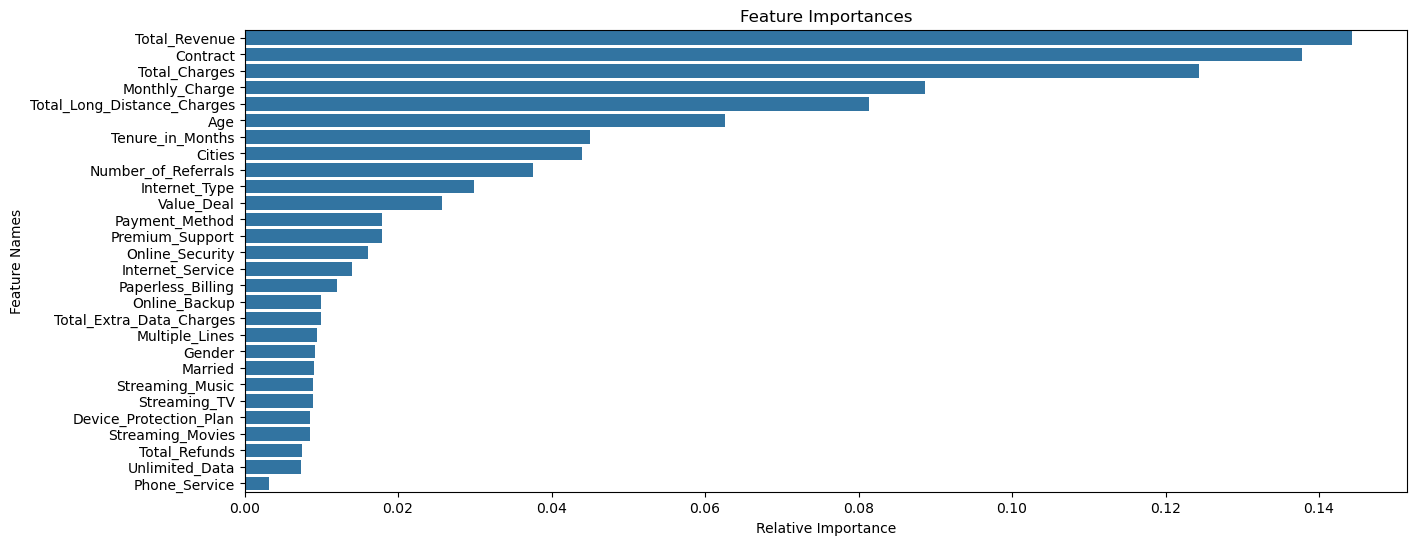

In [15]:
#Evaluate Model
# We are checking importance of all features that we have included in model
# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Selection using Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.show()







In [20]:
print(new_data.dtypes)


Gender                          object
Age                              int64
Married                         object
Cities                          object
Number_of_Referrals              int64
Tenure_in_Months                 int64
Value_Deal                      object
Phone_Service                   object
Multiple_Lines                  object
Internet_Service                object
Internet_Type                   object
Online_Security                 object
Online_Backup                   object
Device_Protection_Plan          object
Premium_Support                 object
Streaming_TV                    object
Streaming_Movies                object
Streaming_Music                 object
Unlimited_Data                  object
Contract                        object
Paperless_Billing               object
Payment_Method                  object
Monthly_Charge                 float64
Total_Charges                  float64
Total_Refunds                  float64
Total_Extra_Data_Charges 

In [22]:
for column in new_data.select_dtypes(include=['object']).columns:
    if column in label_encoders:
        new_data[column] = new_data[column].map(
            lambda s: label_encoders[column].transform([s])[0] if s in label_encoders[column].classes_ else -1
        )

In [23]:
print(new_data.dtypes)

Gender                           int64
Age                              int64
Married                          int64
Cities                           int64
Number_of_Referrals              int64
Tenure_in_Months                 int64
Value_Deal                       int64
Phone_Service                    int64
Multiple_Lines                   int64
Internet_Service                 int64
Internet_Type                    int64
Online_Security                  int64
Online_Backup                    int64
Device_Protection_Plan           int64
Premium_Support                  int64
Streaming_TV                     int64
Streaming_Movies                 int64
Streaming_Music                  int64
Unlimited_Data                   int64
Contract                         int64
Paperless_Billing                int64
Payment_Method                   int64
Monthly_Charge                 float64
Total_Charges                  float64
Total_Refunds                  float64
Total_Extra_Data_Charges 

In [24]:
new_predictions = rf_model.predict(new_data)

In [26]:
#Use Model for Prediction on New Data
# Define the path to the Joiner Data Excel file
file_path = r"C:\Users\keyag\OneDrive\Desktop\Churn_Analysis\Prediction_Data.xlsx"

# Define the sheet name to read data from
sheet_name = 'vw_joinData'

# Read the data from the specified sheet into a pandas DataFrame
new_data = pd.read_excel(file_path, sheet_name=sheet_name)

# Display the first few rows of the fetched data
print(new_data.head())

# Retain the original DataFrame to preserve unencoded columns
original_data = new_data.copy()

# Retain the Customer_ID column
customer_ids = new_data['Customer_ID']

# Drop columns that won't be used for prediction in the encoded DataFrame
#new_data = new_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1)
new_data = new_data.drop(columns=['Customer_ID','Customer_Status','Churn_Category','Churn_Reason'], errors='ignore')

# Encode categorical variables using the saved label encoders
#for column in new_data.select_dtypes(include=['object']).columns:
 #   new_data[column] = label_encoders[column].transform(new_data[column])
for column in new_data.select_dtypes(include=['object']).columns:
    if column in label_encoders:
        new_data[column] = new_data[column].map(
            lambda s: label_encoders[column].transform([s])[0] if s in label_encoders[column].classes_ else -1
        )

# Make predictions
new_predictions = rf_model.predict(new_data)

# Add predictions to the original DataFrame
original_data['Customer_Status_Predicted'] = new_predictions

# Filter the DataFrame to include only records predicted as "Churned"
original_data = original_data[original_data['Customer_Status_Predicted'] == 1]

# Save the results
original_data.to_csv(r"C:\Users\keyag\OneDrive\Desktop\Churn_Analysis\Predictions.csv", index=False)


  Customer_ID  Gender  Age Married       Cities  Number_of_Referrals  \
0   11751-TAM  Female   18      No  Springfield                    5   
1   12056-WES    Male   27      No   Naperville                    2   
2   12136-RAJ  Female   25     Yes     Palatine                    2   
3   12257-ASS  Female   39      No        Elgin                    9   
4   12340-DEL  Female   51     Yes       Aurora                    0   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                 7     Deal 5            No             No  ...   
1                20        NaN           Yes             No  ...   
2                35        NaN           Yes             No  ...   
3                 1        NaN           Yes             No  ...   
4                10        NaN           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0     Mailed Check      24.299999     38.450001           0.0   
1  Bank Withdrawal      90.4